In [2]:
!pip install imbalanced-learn

### Knižnice ###

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    f1_score,
    make_scorer,
    precision_recall_curve,
    average_precision_score,
    roc_auc_score
)

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler

### Data ###

In [8]:
#Načítanie dát zo súboru
df = pd.read_csv("data.csv")

X = df.drop("Bankrupt?", axis=1)
y = df["Bankrupt?"]

#Rozdelenie dát na trénovaciu a testovaciu množinu
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Shape X_train:", X_train.shape)
print("Shape X_test:", X_test.shape)

Shape X_train: (5455, 95)
Shape X_test: (1364, 95)


### Baseline KNN ###

              precision    recall  f1-score   support

           0    0.97407   0.99621   0.98502      1320
           1    0.64286   0.20455   0.31034        44

    accuracy                        0.97067      1364
   macro avg    0.80847   0.60038   0.64768      1364
weighted avg    0.96339   0.97067   0.96326      1364



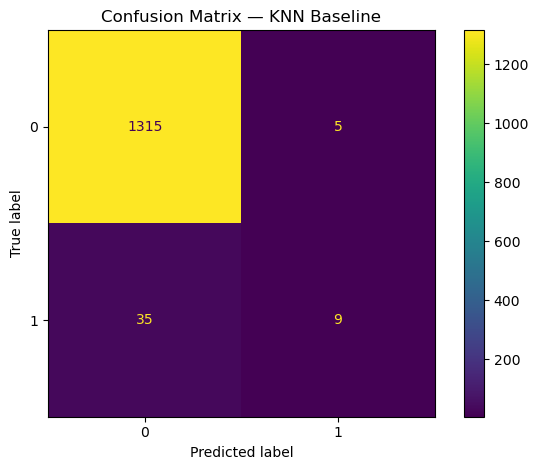

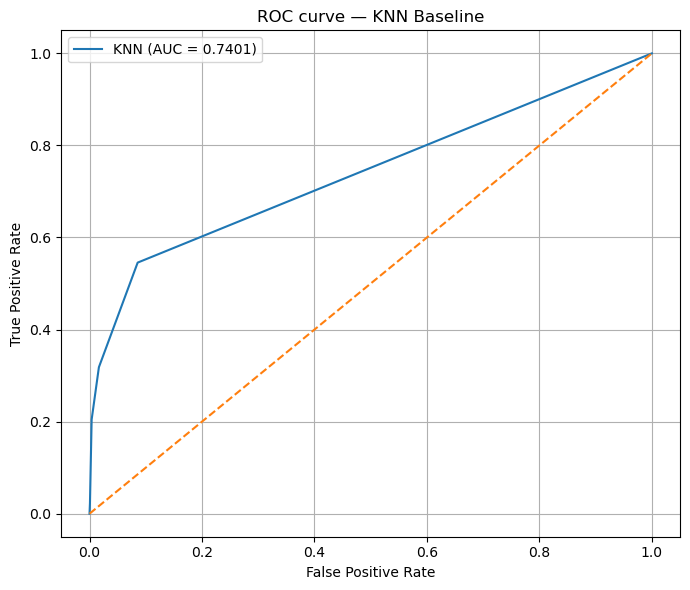

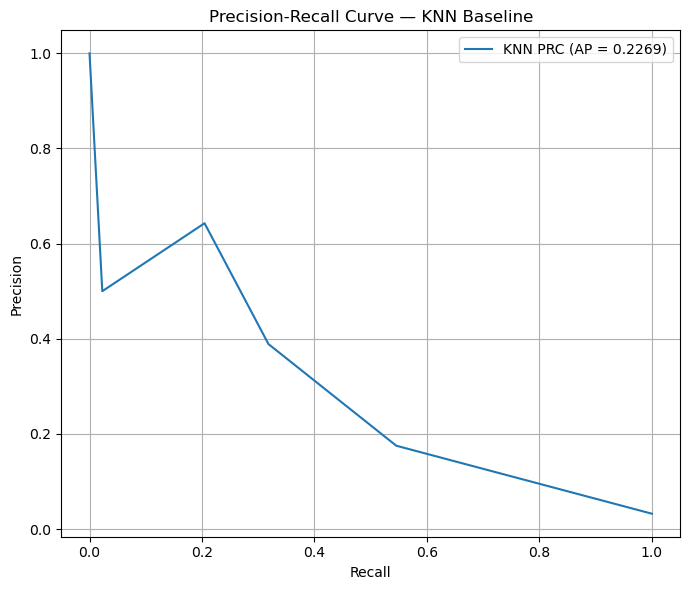

PRC AUC (Average Precision): 0.2269


In [12]:
#Vytvorenie základného KNN modelu s váhou pre nevyvážené triedy
knn1 = ImbPipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

knn1.fit(X_train, y_train)

y_pred1 = knn1.predict(X_test)
y_proba1 = knn1.predict_proba(X_test)[:, 1]

#Výpis reportu klasifikácie
print(classification_report(y_test, y_pred1, digits=5))

#Matica zámen
cm_knn_baseline = confusion_matrix(y_test, y_pred1)
ConfusionMatrixDisplay(cm_knn_baseline).plot()
plt.title("Confusion Matrix — KNN Baseline")
plt.tight_layout()
plt.show()


#ROC krivka
fpr_knn1, tpr_knn1, _ = roc_curve(y_test, y_proba1)
roc_auc_knn1 = auc(fpr_knn1, tpr_knn1)

plt.figure(figsize=(7, 6))
plt.plot(fpr_knn1, tpr_knn1, label=f"KNN (AUC = {roc_auc_knn1:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curve — KNN Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Precision-Recall krivka
precisions_knn1, recalls_knn1, _ = precision_recall_curve(y_test, y_proba1)
prc_auc_knn1 = average_precision_score(y_test, y_proba1)

plt.figure(figsize=(7, 6))
plt.plot(recalls_knn1, precisions_knn1, label=f"KNN PRC (AP = {prc_auc_knn1:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — KNN Baseline")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc_knn1:.4f}")

### Baseline KNN + SMOTE ###

Baseline KNN + SMOTE
              precision    recall  f1-score   support

           0    0.98828   0.89470   0.93917      1320
           1    0.17751   0.68182   0.28169        44

    accuracy                        0.88783      1364
   macro avg    0.58290   0.78826   0.61043      1364
weighted avg    0.96213   0.88783   0.91796      1364


Confusion Matrix
[[1181  139]
 [  14   30]]


<Figure size 600x500 with 0 Axes>

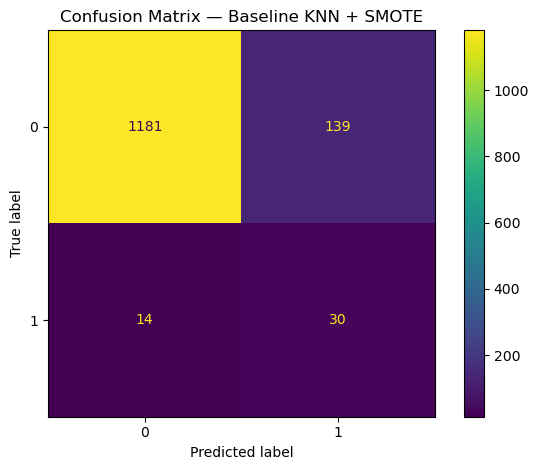

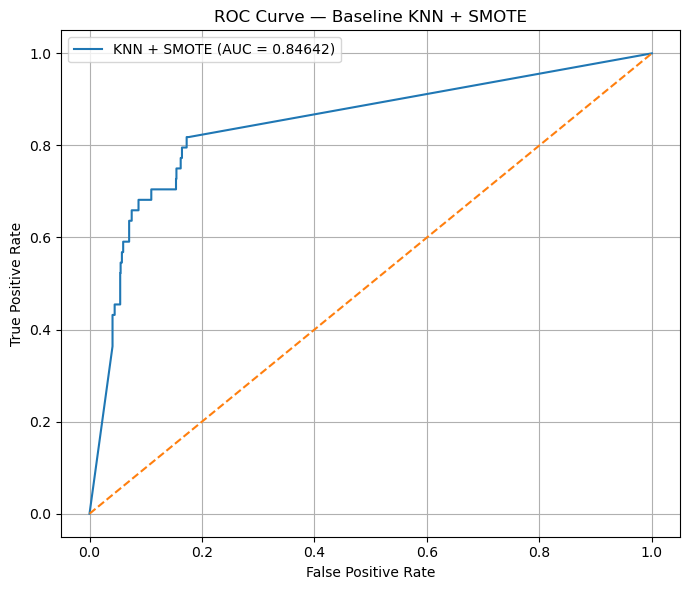

ROC AUC: 0.84642


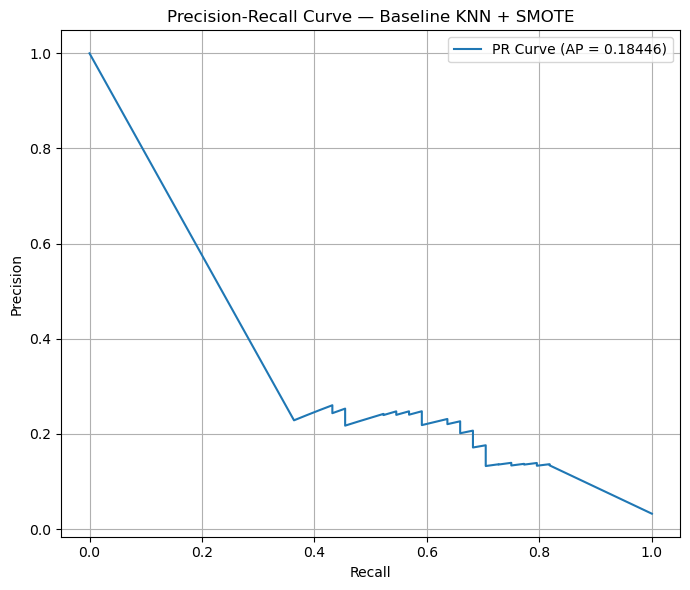

PRC AUC (Average Precision): 0.18446


In [18]:
#Vytvorenie pipeline so SMOTE a KNN modelom
baseline_smote_knn = ImbPipeline(steps=[
    (
        "smote",
        SMOTE(random_state=42)
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "model",
        KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            metric="minkowski",
            p=2
        )
    )
])

#Trénovanie pipeline na trénovacích dátach
baseline_smote_knn.fit(X_train, y_train)

#Trénovanie pipeline na trénovacích dátach
y_pred2 = baseline_smote_knn.predict(X_test)

#Predikcia tried na testovacích dátach
y_proba2 = baseline_smote_knn.predict_proba(X_test)[:, 1]

#Výpis reportu klasifikácie
print("Baseline KNN + SMOTE")
print(classification_report(y_test, y_pred2, digits=5))

#Matica zámen
cm = confusion_matrix(y_test, y_pred2)

print("\nConfusion Matrix")
print(cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay(cm).plot()
plt.title("Confusion Matrix — Baseline KNN + SMOTE")
plt.tight_layout()
plt.show()


#ROC krivka
roc_auc2 = roc_auc_score(y_test, y_proba2)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(fpr_knn, tpr_knn, label=f"KNN + SMOTE (AUC = {roc_auc2:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline KNN + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc2:.5f}")

#Precision-Recall krivka
precisions2, recalls2, _ = precision_recall_curve(y_test, y_proba2)
prc_auc2 = average_precision_score(y_test, y_proba2)

plt.figure(figsize=(7, 6))
plt.plot(recalls2, precisions2, label=f"PR Curve (AP = {prc_auc2:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline KNN + SMOTE")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"PRC AUC (Average Precision): {prc_auc2:.5f}")

### Baseline KNN + ADASYN ###

Classification Report (Baseline KNN + ADASYN)
              precision    recall  f1-score   support

           0    0.98831   0.89697   0.94043      1320
           1    0.18072   0.68182   0.28571        44

    accuracy                        0.89003      1364
   macro avg    0.58452   0.78939   0.61307      1364
weighted avg    0.96226   0.89003   0.91931      1364


Confusion Matrix
[[1184  136]
 [  14   30]]


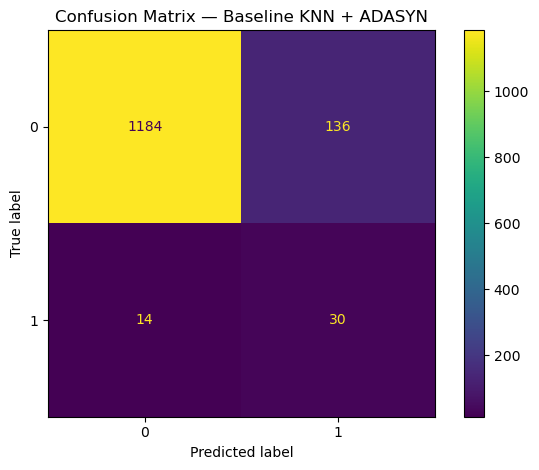

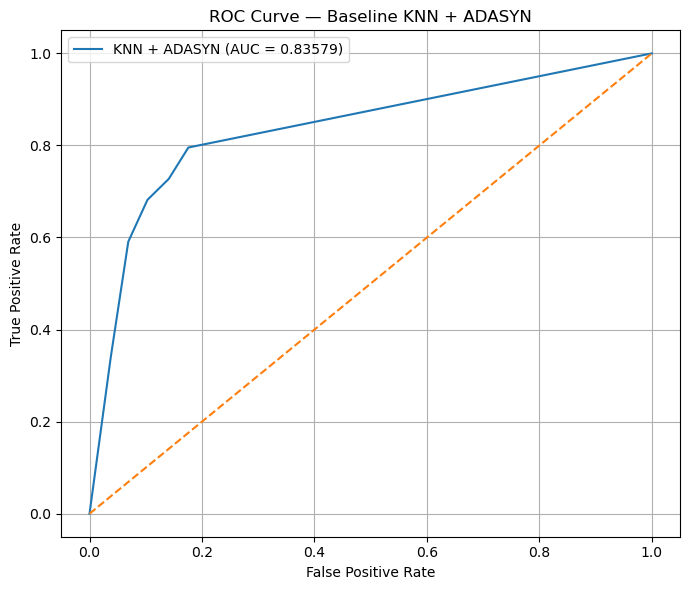

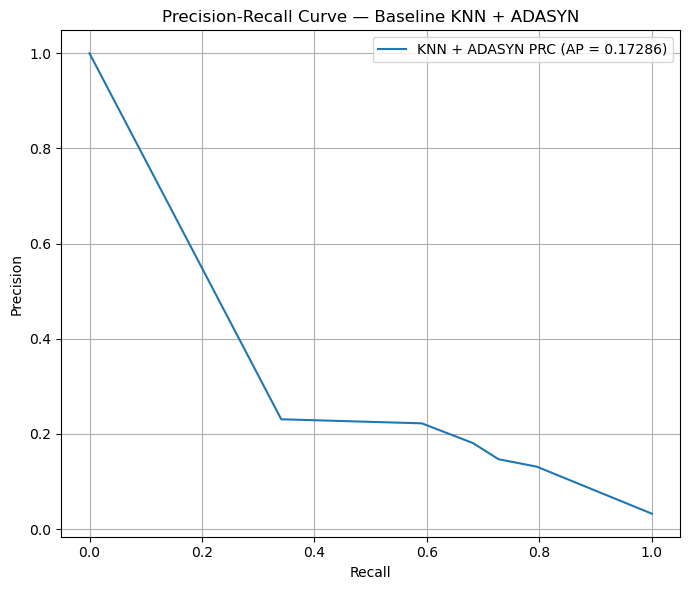

ROC AUC: 0.83579
PRC AUC: 0.17286


In [20]:
#Vytvorenie pipeline s ADASYN a KNN modelom
baseline_adasyn_knn = ImbPipeline(steps=[
    ("adasyn", ADASYN(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

#Trénovanie modelu na trénovacích dátach
baseline_adasyn_knn.fit(X_train, y_train)

#Predikcia tried na testovacích dátach
y_pred3 = baseline_adasyn_knn.predict(X_test)

# Predikcia pravdepodobnosti pre triedu 1
y_proba3 = baseline_adasyn_knn.predict_proba(X_test)[:, 1]

#Výpis reportu klasifikácie
print("Classification Report (Baseline KNN + ADASYN)")
print(classification_report(y_test, y_pred3, digits=5))

roc_auc3 = roc_auc_score(y_test, y_proba3)
prc_auc3 = average_precision_score(y_test, y_proba3)

#Matica zámen
cm3 = confusion_matrix(y_test, y_pred3)
print("\nConfusion Matrix")
print(cm3)

ConfusionMatrixDisplay(cm3).plot()
plt.title("Confusion Matrix — Baseline KNN + ADASYN")
plt.tight_layout()
plt.show()


#ROC krivka
fpr3, tpr3, _ = roc_curve(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(fpr3, tpr3, label=f"KNN + ADASYN (AUC = {roc_auc3:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Baseline KNN + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
precisions3, recalls3, _ = precision_recall_curve(y_test, y_proba3)

plt.figure(figsize=(7, 6))
plt.plot(recalls3, precisions3, label=f"KNN + ADASYN PRC (AP = {prc_auc3:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Baseline KNN + ADASYN")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc3:.5f}")
print(f"PRC AUC: {prc_auc3:.5f}")

### KNN + UnderSampling + SMOTE + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best params:
{'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'uniform', 'smote__k_neighbors': 5, 'smote__sampling_strategy': 0.25, 'under__sampling_strategy': 0.05}
F1-score (CV): 0.3902
Best threshold: 0.6000
Best F1 from PR curve: 0.4961

Classification Report (KNN + UnderSampling + SMOTE + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0    0.99062   0.95985   0.97499      1320
           1    0.37647   0.72727   0.49612        44

    accuracy                        0.95235      1364
   macro avg    0.68354   0.84356   0.73556      1364
weighted avg    0.97081   0.95235   0.95954      1364


Confusion Matrix
[[1267   53]
 [  12   32]]


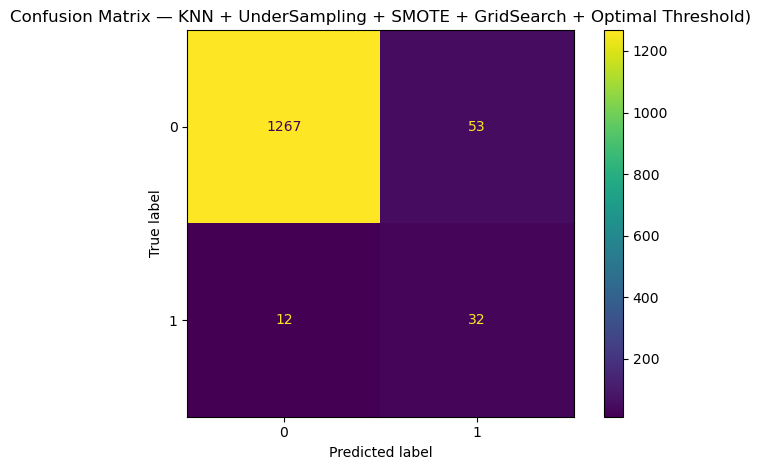

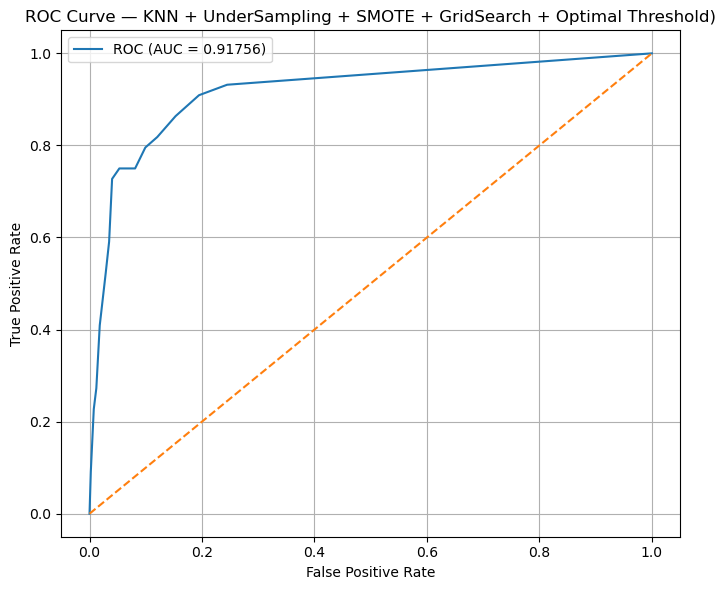

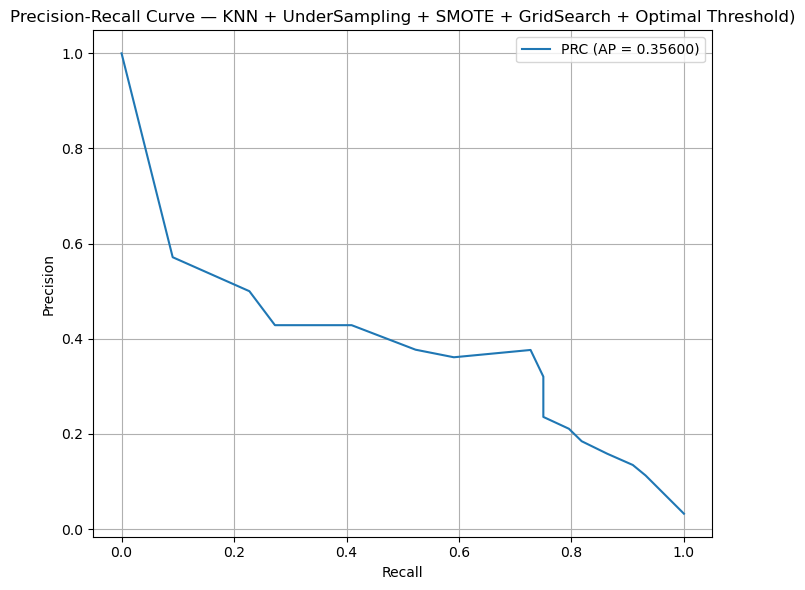

ROC AUC: 0.91756
PRC AUC: 0.35600


In [36]:
#Vytvorenie pipeline s undersamplingom, SMOTE a KNN modelom
pipe = ImbPipeline(steps=[
    ("under", RandomUnderSampler(random_state=42)),
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

#Definovanie rozsahu hyperparametrov pre GridSearch
param_grid = {
    "under__sampling_strategy": [0.05, 0.08],
    "smote__sampling_strategy": [0.25, 0.30],
    "smote__k_neighbors": [3, 5],

    "model__n_neighbors": [7, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#Definovanie hodnotiacej metriky F1-score
scorer = make_scorer(f1_score, pos_label=1)

#Nastavenie GridSearchCV pre hľadanie najlepších parametrov
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

#Spustenie trénovania a hľadania najlepšieho modelu
grid_search.fit(X_train, y_train)

#Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

#Uloženie najlepšieho modelu
best_model1 = grid_search.best_estimator_

#Výpočet pravdepodobností pre triedu 1
y_proba4 = best_model1.predict_proba(X_test)[:, 1]

precisions4, recalls4, thresholds4 = precision_recall_curve(y_test, y_proba4)

#Výpočet F1-score pre rôzne prahy
f1_scores = 2 * (precisions4[:-1] * recalls4[:-1]) / (precisions4[:-1] + recalls4[:-1] + 1e-10)
best_threshold = thresholds4[np.argmax(f1_scores)]

#Výber prahu s najvyšším F1-score
print(f"Best threshold: {best_threshold:.4f}")
print(f"Best F1 from PR curve: {np.max(f1_scores):.4f}")

#Predikcia tried podľa optimálneho prahu
y_pred4 = (y_proba4 >= best_threshold).astype(int)

#Výpis reportu klasifikácie
print("\nClassification Report (KNN + UnderSampling + SMOTE + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred4, digits=5))

roc_auc4 = roc_auc_score(y_test, y_proba4)
prc_auc4 = average_precision_score(y_test, y_proba4)

#Matica zámen
cm_opt = confusion_matrix(y_test, y_pred4)
print("\nConfusion Matrix")
print(cm_opt)

ConfusionMatrixDisplay(cm_opt).plot()
plt.title("Confusion Matrix — KNN + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
fpr4, tpr4, _ = roc_curve(y_test, y_proba4)

plt.figure(figsize=(7, 6))
plt.plot(fpr4, tpr4, label=f"ROC (AUC = {roc_auc4:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


#Precision-Recall krivka
plt.figure(figsize=(7, 6))
plt.plot(recalls4, precisions4, label=f"PRC (AP = {prc_auc4:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — KNN + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc4:.5f}")
print(f"PRC AUC: {prc_auc4:.5f}")

### KNN + UnderSampling + ADASYN + GridSearch + Optimal Threshold ###

Fitting 5 folds for each of 96 candidates, totalling 480 fits

Best params:
{'adasyn__n_neighbors': 3, 'adasyn__sampling_strategy': 0.25, 'model__metric': 'manhattan', 'model__n_neighbors': 15, 'model__weights': 'distance', 'under__sampling_strategy': 0.08}
F1-score (CV): 0.4060
Best threshold: 0.6261
Best F1 from PR curve: 0.5102

Classification Report (KNN + UnderSampling + ADASYN + GridSearch + Optimal Threshold)
              precision    recall  f1-score   support

           0    0.98550   0.97803   0.98175      1320
           1    0.46296   0.56818   0.51020        44

    accuracy                        0.96481      1364
   macro avg    0.72423   0.77311   0.74598      1364
weighted avg    0.96864   0.96481   0.96654      1364


Confusion Matrix
[[1291   29]
 [  19   25]]


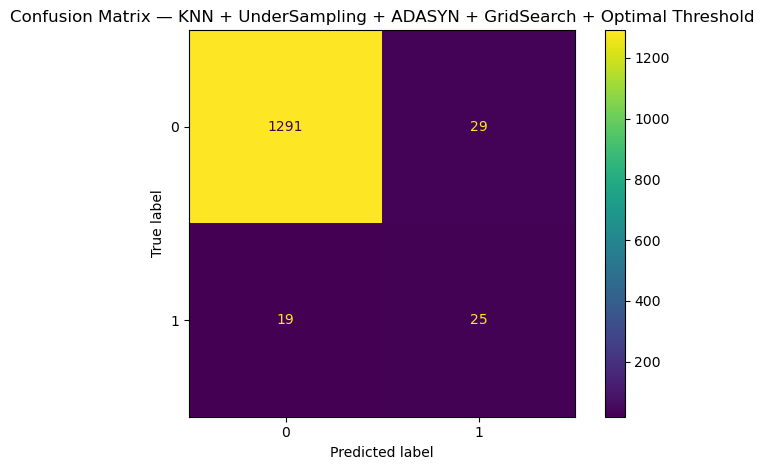

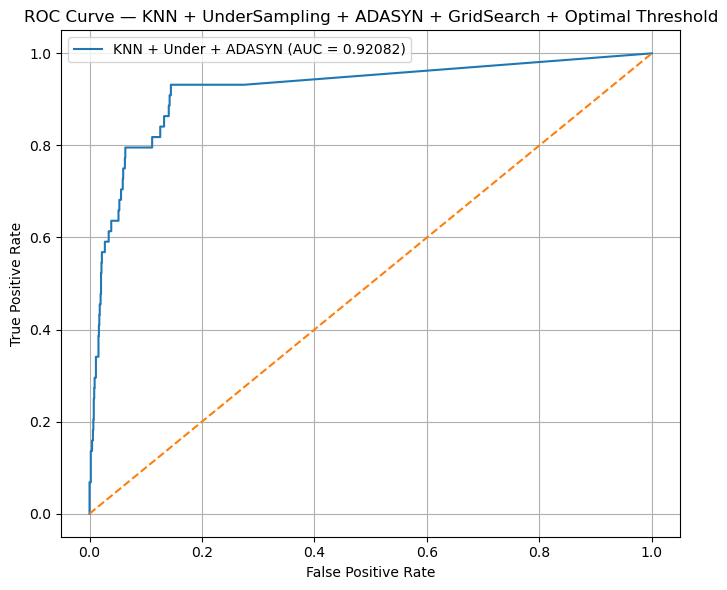

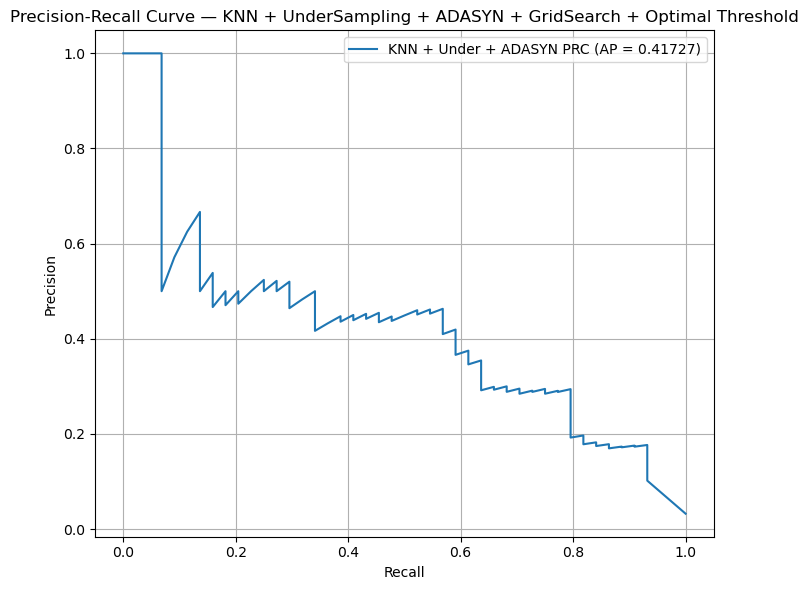

ROC AUC: 0.92082
PRC AUC: 0.41727


In [38]:
#Vytvorenie pipeline s undersamplingom, ADASYN a KNN modelom
pipe = ImbPipeline(steps=[
    ("under", RandomUnderSampler(random_state=42)),
    ("adasyn", ADASYN(random_state=42)),
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

#Definovanie hyperparametrov pre GridSearch
param_grid = {
    "under__sampling_strategy": [0.05, 0.08],
    "adasyn__sampling_strategy": [0.25, 0.30],
    "adasyn__n_neighbors": [3, 5],

    "model__n_neighbors": [7, 11, 15],
    "model__weights": ["uniform", "distance"],
    "model__metric": ["euclidean", "manhattan"]
}

#Nastavenie stratifikovanej krížovej validácie
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Nastavenie F1-score ako hodnotiacej metriky
scorer = make_scorer(f1_score, pos_label=1)

# Vytvorenie GridSearchCV
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring=scorer,
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=False,
    refit=True
)

# Trénovanie modelu a hľadanie najlepších parametrov
grid_search.fit(X_train, y_train)

# Výpis najlepších parametrov
print("\nBest params:")
print(grid_search.best_params_)

# Výpis najlepšieho F1-score z krížovej validácie
print(f"F1-score (CV): {grid_search.best_score_:.4f}")

# Uloženie najlepšieho modelu
best_model2 = grid_search.best_estimator_

# Výpočet pravdepodobností pre triedu 1
y_proba5 = best_model2.predict_proba(X_test)[:, 1]

# Výpočet hodnôt pre Precision-Recall krivku
precisions5, recalls5, thresholds5 = precision_recall_curve(y_test, y_proba5)

# Výpočet F1-score pre rôzne prahy
f1_scores5 = 2 * (precisions5[:-1] * recalls5[:-1]) / (
    precisions5[:-1] + recalls5[:-1] + 1e-10
)

# Výber najlepšieho prahu podľa F1-score
best_threshold5 = thresholds5[np.argmax(f1_scores5)]
print(f"Best threshold: {best_threshold5:.4f}")
print(f"Best F1 from PR curve: {np.max(f1_scores5):.4f}")

# Predikcia tried podľa optimálneho prahu
y_pred5 = (y_proba5 >= best_threshold5).astype(int)

#Výpis reportu klasifikácie
print("\nClassification Report (KNN + UnderSampling + ADASYN + GridSearch + Optimal Threshold)")
print(classification_report(y_test, y_pred5, digits=5))

roc_auc5 = roc_auc_score(y_test, y_proba5)
prc_auc5 = average_precision_score(y_test, y_proba5)

#Matica zámen
cm_opt2 = confusion_matrix(y_test, y_pred5)
print("\nConfusion Matrix")
print(cm_opt2)

ConfusionMatrixDisplay(cm_opt2).plot()
plt.title("Confusion Matrix — KNN + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()


#ROC krivka
fpr5, tpr5, _ = roc_curve(y_test, y_proba5)

plt.figure(figsize=(7, 6))
plt.plot(fpr5, tpr5, label=f"KNN + Under + ADASYN (AUC = {roc_auc5:.5f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#Precision-Recall krivka
plt.figure(figsize=(7, 6))
plt.plot(recalls5, precisions5, label=f"KNN + Under + ADASYN PRC (AP = {prc_auc5:.5f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — KNN + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"ROC AUC: {roc_auc5:.5f}")
print(f"PRC AUC: {prc_auc5:.5f}")

### Výsledky všetkých modelov ###

In [40]:
print("Baseline KNN")
print(classification_report(y_test, y_pred1))

print("Baseline KNN + SMOTE")
print(classification_report(y_test, y_pred2))

print("Baseline KNN + ADASYN")
print(classification_report(y_test, y_pred3))

print("\nKNN + UnderSampling + SMOTE + GridSearch + Optimal Threshold")
print(classification_report(y_test, y_pred4))

print("\nKNN + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
print(classification_report(y_test, y_pred5))

Baseline KNN
              precision    recall  f1-score   support

           0       0.97      1.00      0.99      1320
           1       0.64      0.20      0.31        44

    accuracy                           0.97      1364
   macro avg       0.81      0.60      0.65      1364
weighted avg       0.96      0.97      0.96      1364

Baseline KNN + SMOTE
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1320
           1       0.18      0.68      0.28        44

    accuracy                           0.89      1364
   macro avg       0.58      0.79      0.61      1364
weighted avg       0.96      0.89      0.92      1364

Baseline KNN + ADASYN
              precision    recall  f1-score   support

           0       0.99      0.90      0.94      1320
           1       0.18      0.68      0.29        44

    accuracy                           0.89      1364
   macro avg       0.58      0.79      0.61      1364
weighted avg      

### Permutation importance ###

Top 10 Feature Importance (Permutation Importance)
                                      feature  importance_mean
18    Persistent EPS in the Last Four Seasons         0.040909
67          Retained Earnings to Total Assets         0.036364
81                              CFO to Assets         0.027273
30       Total Asset Return Growth Rate Ratio         0.027273
28                    Total Asset Growth Rate         0.022727
22   Per Share Net profit before tax (Yuan ¥)         0.022727
42      Net profit before tax/Paid-in capital         0.022727
80                     Cash Flow to Liability         0.022727
79                  Cash Flow to Total Assets         0.018182
31                        Cash Reinvestment %         0.018182


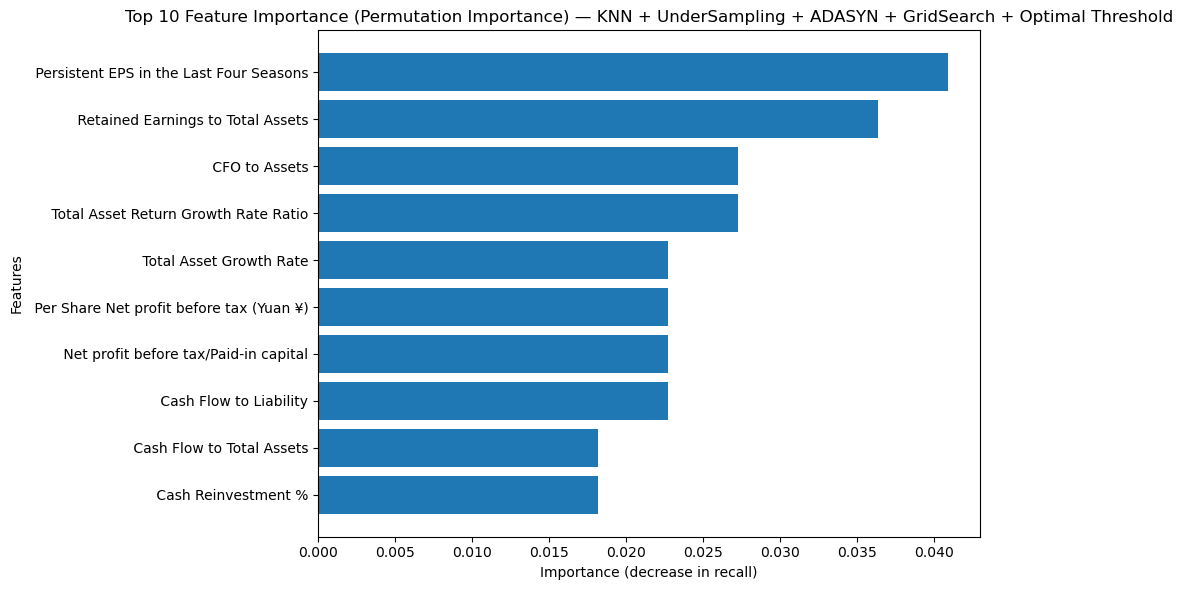

In [54]:
#Vytvorenie kópie testovacích dát
X_test_imp = X_test.copy()

#Výpočet permutation importance pre najlepší model
result = permutation_importance(
    estimator=best_model2,
    X=X_test_imp,
    y=y_test,
    scoring="recall",
    n_repeats=5,
    random_state=42,
    n_jobs=1
)

#Vytvorenie tabuľky s dôležitosťou premenných
importance_df = pd.DataFrame({
    "feature": X_test_imp.columns,
    "importance_mean": result.importances_mean
}).sort_values(by="importance_mean", ascending=False)

#Výpis 10 najdôležitejších premenných
print("Top 10 Feature Importance (Permutation Importance)")
print(importance_df.head(10))

#Výber 10 najdôležitejších premenných
top10 = importance_df.head(10)

#Vykreslenie grafu dôležitosti premenných
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Importance (decrease in recall)")
plt.ylabel("Features")
plt.title("Top 10 Feature Importance (Permutation Importance) — KNN + UnderSampling + ADASYN + GridSearch + Optimal Threshold")
plt.tight_layout()
plt.show()

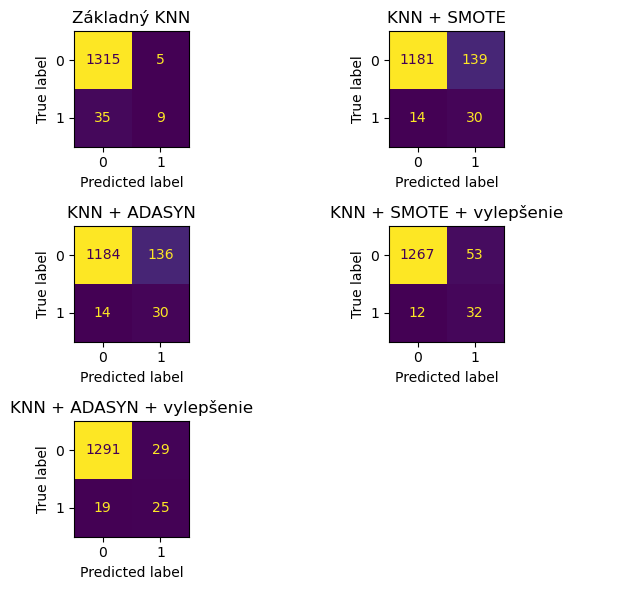

In [63]:
fig, axes = plt.subplots(3, 2, figsize=(7, 6))

cm1 = confusion_matrix(y_test, y_pred1)
ConfusionMatrixDisplay(cm1).plot(ax=axes[0, 0], colorbar=False)
axes[0, 0].set_title("Základný KNN")

cm2 = confusion_matrix(y_test, y_pred2)
ConfusionMatrixDisplay(cm2).plot(ax=axes[0, 1], colorbar=False)
axes[0, 1].set_title("KNN + SMOTE")

cm3 = confusion_matrix(y_test, y_pred3)
ConfusionMatrixDisplay(cm3).plot(ax=axes[1, 0], colorbar=False)
axes[1, 0].set_title("KNN + ADASYN")

cm4 = confusion_matrix(y_test, y_pred4)
ConfusionMatrixDisplay(cm4).plot(ax=axes[1, 1], colorbar=False)
axes[1, 1].set_title("KNN + SMOTE + vylepšenie")

cm5 = confusion_matrix(y_test, y_pred5)
ConfusionMatrixDisplay(cm5).plot(ax=axes[2, 0], colorbar=False)
axes[2, 0].set_title("KNN + ADASYN + vylepšenie")

axes[2, 1].axis("off")

plt.tight_layout()
plt.show()

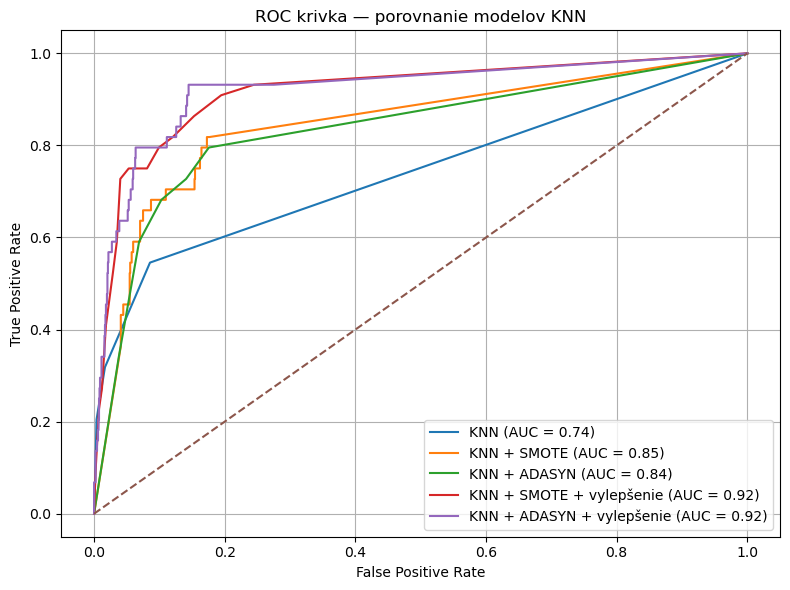

In [67]:
plt.figure(figsize=(8, 6))

plt.plot(fpr_knn1, tpr_knn1, label=f"KNN (AUC = {roc_auc_knn1:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN + SMOTE (AUC = {roc_auc2:.2f})")
plt.plot(fpr3, tpr3, label=f"KNN + ADASYN (AUC = {roc_auc3:.2f})")
plt.plot(fpr4, tpr4, label=f"KNN + SMOTE + vylepšenie (AUC = {roc_auc4:.2f})")
plt.plot(fpr5, tpr5, label=f"KNN + ADASYN + vylepšenie (AUC = {roc_auc5:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC krivka — porovnanie modelov KNN")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

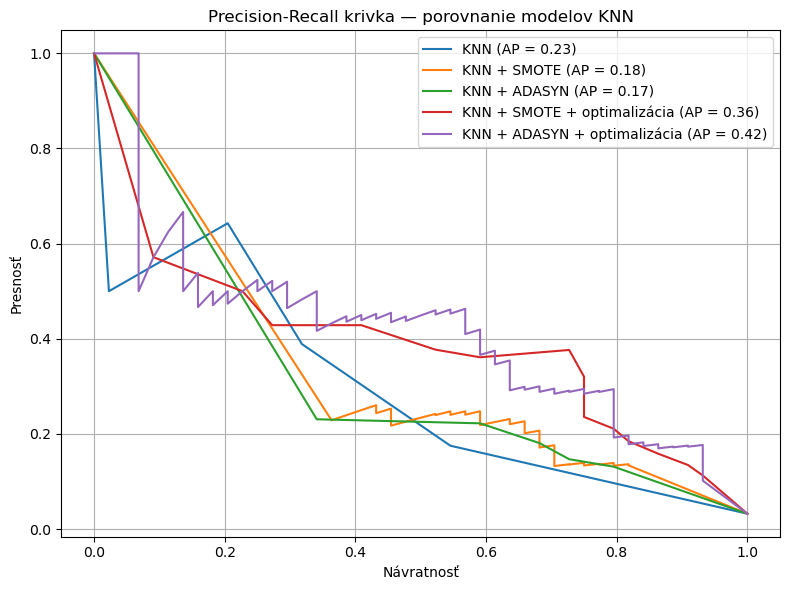

In [70]:
plt.figure(figsize=(8, 6))

plt.plot(recalls_knn1, precisions_knn1, label=f"KNN (AP = {prc_auc_knn1:.2f})")
plt.plot(recalls2, precisions2, label=f"KNN + SMOTE (AP = {prc_auc2:.2f})")
plt.plot(recalls3, precisions3, label=f"KNN + ADASYN (AP = {prc_auc3:.2f})")
plt.plot(recalls4, precisions4, label=f"KNN + SMOTE + optimalizácia (AP = {prc_auc4:.2f})")
plt.plot(recalls5, precisions5, label=f"KNN + ADASYN + optimalizácia (AP = {prc_auc5:.2f})")

plt.xlabel("Návratnosť")
plt.ylabel("Presnosť")
plt.title("Precision-Recall krivka — porovnanie modelov KNN")

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()